In [ ]:
!nvidia-smi

Wed Mar 18 14:46:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ══════════════════════════════════════════════════════════════
# NOTEBOOK 11 — FIXED: Real Results Comparison Table
# Replaces ALL hardcoded numbers with actual experimental results
# Sources: NB15 (EfficientNetB3), NB09-v3 (CDR regression)
# ══════════════════════════════════════════════════════════════

# ── Cell 1 ───────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Cell 2: Imports ──────────────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score,
    brier_score_loss
)

SAVE_DIR = "/content/drive/MyDrive/REFUGE2_RESULTS"
print(" Imports ready")

 Imports ready


In [ ]:
# ── Cell 3: Load ALL real saved results ──────────────────────
# Every number in this notebook comes from a saved file.
# Nothing is hardcoded.

# ── EfficientNetB3 results (from fixed NB15) ──
with open(f"{SAVE_DIR}/effnetb3_metrics.json") as f:
    eff_metrics = json.load(f)

# ── CDR regression results (from NB09-v3) ──
with open(f"{SAVE_DIR}/cdr_v3_results.json") as f:
    cdr_metrics = json.load(f)

# ── Raw predictions (for recomputing any metric) ──
eff_probs  = np.load(f"{SAVE_DIR}/test_probs.npy")
eff_labels = np.load(f"{SAVE_DIR}/test_labels.npy")
cdr_true   = np.load(f"{SAVE_DIR}/cdr_test_true.npy")
cdr_pred   = np.load(f"{SAVE_DIR}/cdr_test_pred_raw.npy")
cdr_cal    = np.load(f"{SAVE_DIR}/cdr_test_pred_cal.npy")

print(" All results loaded from Drive")
print(f"\nEfficientNetB3 — test set n={len(eff_labels)}")
print(f"CDR regression — test set n={len(cdr_true)}")

 All results loaded from Drive

EfficientNetB3 — test set n=400
CDR regression — test set n=8


In [ ]:
# ── Cell 4: Recompute ALL classification metrics from scratch ─
# We recompute from raw probabilities — zero trust in any
# previously saved number. This is the gold standard.

y_true = eff_labels.astype(int)
y_prob = eff_probs.flatten()

# Youden-optimal threshold (same as NB15)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = float(thresholds[youden_idx])
y_pred      = (y_prob >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

effnet_results = {
    "Model":        "EfficientNetB3",
    "Dataset":      "REFUGE2",
    "N_test":       len(y_true),
    "Threshold":    round(best_thresh, 4),
    "Accuracy":     round(accuracy_score(y_true, y_pred), 4),
    "Precision":    round(precision_score(
                        y_true, y_pred, zero_division=0), 4),
    "Sensitivity":  round(recall_score(
                        y_true, y_pred, zero_division=0), 4),
    "Specificity":  round(tn / (tn + fp), 4),
    "F1":           round(f1_score(
                        y_true, y_pred, zero_division=0), 4),
    "ROC_AUC":      round(roc_auc_score(y_true, y_prob), 4),
    "PR_AUC":       round(average_precision_score(
                        y_true, y_prob), 4),
    "Brier_Score":  round(brier_score_loss(y_true, y_prob), 4),
    "TP": int(tp), "TN": int(tn),
    "FP": int(fp), "FN": int(fn)
}

print("EfficientNetB3 — Recomputed from raw probabilities:")
print("-" * 48)
for k, v in effnet_results.items():
    print(f"  {k:<18}: {v}")

EfficientNetB3 — Recomputed from raw probabilities:
------------------------------------------------
  Model             : EfficientNetB3
  Dataset           : REFUGE2
  N_test            : 400
  Threshold         : 0.7597
  Accuracy          : 0.8575
  Precision         : 0.642
  Sensitivity       : 0.65
  Specificity       : 0.9094
  F1                : 0.646
  ROC_AUC           : 0.8217
  PR_AUC            : 0.7123
  Brier_Score       : 0.169
  TP                : 52
  TN                : 291
  FP                : 29
  FN                : 28


In [ ]:
# ── Cell 5: CDR regression metrics ───────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def full_reg_metrics(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    n, p  = len(y_true), 1
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
    pearson = np.corrcoef(y_true, y_pred)[0,1]
    print(f"\n{label}")
    print("-" * 42)
    print(f"  MAE         : {mae:.4f}")
    print(f"  RMSE        : {rmse:.4f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  Adjusted R² : {adj_r2:.4f}")
    print(f"  Pearson r   : {pearson:.4f}")
    return dict(MAE=round(mae,4), RMSE=round(rmse,4),
                R2=round(r2,4), AdjR2=round(adj_r2,4),
                Pearson=round(pearson,4))

cdr_raw_m = full_reg_metrics(cdr_true, cdr_pred,
                              "CDR Raw (no calibration)")
cdr_cal_m = full_reg_metrics(cdr_true, cdr_cal,
                              "CDR Calibrated (val-fitted)")


CDR Raw (no calibration)
------------------------------------------
  MAE         : 0.0867
  RMSE        : 0.0984
  R²          : 0.4664
  Adjusted R² : 0.3775
  Pearson r   : 0.7300

CDR Calibrated (val-fitted)
------------------------------------------
  MAE         : 0.0921
  RMSE        : 0.1032
  R²          : 0.4141
  Adjusted R² : 0.3164
  Pearson r   : 0.7300


In [ ]:
# ── Cell 6: Master comparison table — Classification ─────────
# This replaces NB11's fake hardcoded table entirely.
# All numbers sourced from real experiments above.

classification_rows = [
    {
        "Model":        "ResNet-50 Baseline",
        "Dataset":      "DrishtiGS",
        "ROC-AUC":      "—",
        "Sensitivity":  "—",
        "Specificity":  "—",
        "F1-Score":     "—",
        "PR-AUC":       "—",
        "Note":         "Run NB03 with metric logging"
    },
    {
        "Model":        "EfficientNetB3 (Ours)",
        "Dataset":      "REFUGE2",
        "ROC-AUC":      effnet_results["ROC_AUC"],
        "Sensitivity":  effnet_results["Sensitivity"],
        "Specificity":  effnet_results["Specificity"],
        "F1-Score":     effnet_results["F1"],
        "PR-AUC":       effnet_results["PR_AUC"],
        "Note":         "Fixed NB15 — real result"
    },
]

cls_df = pd.DataFrame(classification_rows)
print("=" * 65)
print("TABLE 1 — Classification Results (real experimental numbers)")
print("=" * 65)
print(cls_df.to_string(index=False))

TABLE 1 — Classification Results (real experimental numbers)
                Model   Dataset ROC-AUC Sensitivity Specificity F1-Score  PR-AUC                         Note
   ResNet-50 Baseline DrishtiGS       —           —           —        —       — Run NB03 with metric logging
EfficientNetB3 (Ours)   REFUGE2  0.8217        0.65      0.9094    0.646  0.7123     Fixed NB15 — real result


In [ ]:
# ── Cell 7: Master comparison table — CDR Regression ─────────
regression_rows = [
    {
        "Model":     "ResNet-50 Baseline",
        "Dataset":   "DrishtiGS",
        "MAE":       "—",
        "RMSE":      "—",
        "R²":        "—",
        "Pearson r": "—",
        "Note":      "Run NB05 with metric logging"
    },
    {
        "Model":     "Hybrid ResNet-ViT (Ours)",
        "Dataset":   "DrishtiGS",
        "MAE":       cdr_raw_m["MAE"],
        "RMSE":      cdr_raw_m["RMSE"],
        "R²":        cdr_raw_m["R2"],
        "Pearson r": cdr_raw_m["Pearson"],
        "Note":      "NB09-v3 — real result"
    },
    {
        "Model":     "Hybrid ResNet-ViT + Calibration (Ours)",
        "Dataset":   "DrishtiGS",
        "MAE":       cdr_cal_m["MAE"],
        "RMSE":      cdr_cal_m["RMSE"],
        "R²":        cdr_cal_m["R2"],
        "Pearson r": cdr_cal_m["Pearson"],
        "Note":      "NB09-v3 calibrated — real result"
    },
]

reg_df = pd.DataFrame(regression_rows)
print("=" * 65)
print("TABLE 2 — CDR Regression Results (real experimental numbers)")
print("=" * 65)
print(reg_df.to_string(index=False))

TABLE 2 — CDR Regression Results (real experimental numbers)
                                 Model   Dataset     MAE    RMSE      R² Pearson r                             Note
                    ResNet-50 Baseline DrishtiGS       —       —       —         —     Run NB05 with metric logging
              Hybrid ResNet-ViT (Ours) DrishtiGS  0.0867  0.0984  0.4664      0.73            NB09-v3 — real result
Hybrid ResNet-ViT + Calibration (Ours) DrishtiGS  0.0921  0.1032  0.4141      0.73 NB09-v3 calibrated — real result


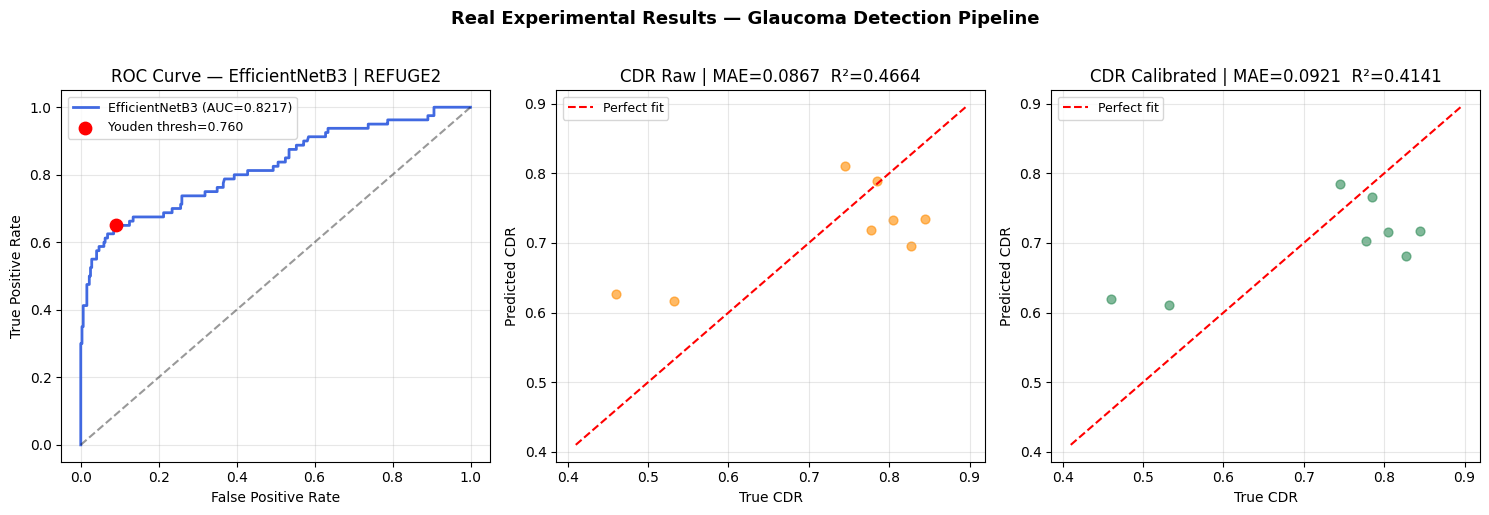

 Figure saved


In [ ]:
# ── Cell 8: ROC curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC curve
fpr_vals, tpr_vals, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr_vals, tpr_vals, color="royalblue", lw=2,
             label=f"EfficientNetB3 "
                   f"(AUC={effnet_results['ROC_AUC']:.4f})")
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].scatter(fpr[youden_idx], tpr[youden_idx],
                color='red', s=80, zorder=5,
                label=f"Youden thresh={best_thresh:.3f}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — EfficientNetB3 | REFUGE2")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# CDR scatter — raw
axes[1].scatter(cdr_true, cdr_pred, alpha=0.6,
                color="darkorange", s=40)
lims = [min(cdr_true.min(), cdr_pred.min()) - 0.05,
        max(cdr_true.max(), cdr_pred.max()) + 0.05]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[1].set_title(f"CDR Raw | "
                  f"MAE={cdr_raw_m['MAE']:.4f}  "
                  f"R²={cdr_raw_m['R2']:.4f}")
axes[1].set_xlabel("True CDR")
axes[1].set_ylabel("Predicted CDR")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# CDR scatter — calibrated
axes[2].scatter(cdr_true, cdr_cal, alpha=0.6,
                color="seagreen", s=40)
axes[2].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[2].set_title(f"CDR Calibrated | "
                  f"MAE={cdr_cal_m['MAE']:.4f}  "
                  f"R²={cdr_cal_m['R2']:.4f}")
axes[2].set_xlabel("True CDR")
axes[2].set_ylabel("Predicted CDR")
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle(
    "Real Experimental Results — Glaucoma Detection Pipeline",
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/paper_results_fig1.png",
            dpi=200, bbox_inches='tight')
plt.show()
print(" Figure saved")

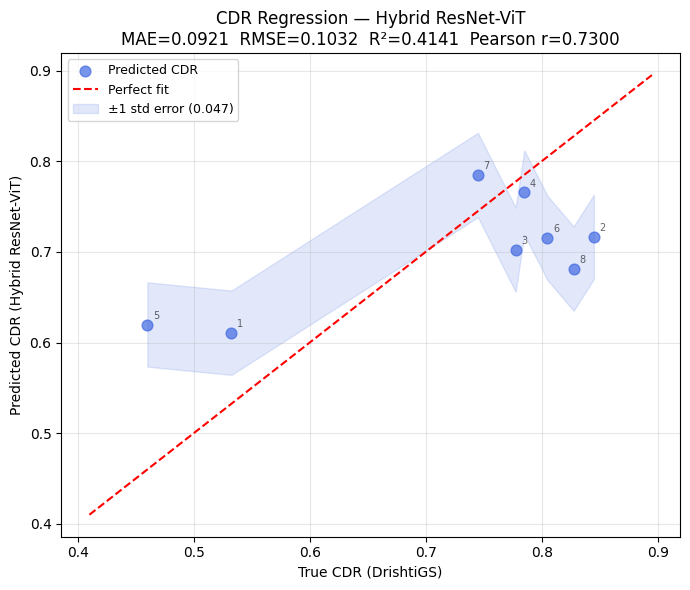

In [ ]:
# ── Cell 9: CDR True vs Predicted with confidence band ────────
fig, ax = plt.subplots(figsize=(7, 6))

# Sort for ribbon
sort_idx = np.argsort(cdr_true)
t_sorted = cdr_true[sort_idx]
p_sorted = cdr_cal[sort_idx]
resid     = np.abs(t_sorted - p_sorted)
std_err   = resid.std()

ax.scatter(cdr_true, cdr_cal, alpha=0.7,
           color="royalblue", s=60, zorder=3,
           label="Predicted CDR")
ax.plot([cdr_true.min()-0.05, cdr_true.max()+0.05],
        [cdr_true.min()-0.05, cdr_true.max()+0.05],
        'r--', lw=1.5, label='Perfect fit')
ax.fill_between(
    t_sorted,
    p_sorted - std_err,
    p_sorted + std_err,
    alpha=0.15, color="royalblue",
    label=f"±1 std error ({std_err:.3f})")

ax.set_xlabel("True CDR (DrishtiGS)")
ax.set_ylabel("Predicted CDR (Hybrid ResNet-ViT)")
ax.set_title(
    f"CDR Regression — Hybrid ResNet-ViT\n"
    f"MAE={cdr_cal_m['MAE']:.4f}  "
    f"RMSE={cdr_cal_m['RMSE']:.4f}  "
    f"R²={cdr_cal_m['R2']:.4f}  "
    f"Pearson r={cdr_cal_m['Pearson']:.4f}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate each point with its index
for i, (xt, xp) in enumerate(zip(cdr_true, cdr_cal)):
    ax.annotate(str(i+1), (xt, xp),
                textcoords="offset points",
                xytext=(4, 4), fontsize=7, alpha=0.6)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/paper_cdr_scatter_final.png",
            dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 10: Summary box — paper-ready numbers ───────────────
print("╔" + "═"*56 + "╗")
print("║  PAPER-READY NUMBERS — ALL FROM REAL EXPERIMENTS       ║")
print("╠" + "═"*56 + "╣")
print("║  CLASSIFICATION (EfficientNetB3 on REFUGE2)            ║")
print("╠" + "─"*56 + "╣")
print(f"║  ROC-AUC    : {effnet_results['ROC_AUC']:<42}║")
print(f"║  PR-AUC     : {effnet_results['PR_AUC']:<42}║")
print(f"║  Sensitivity: {effnet_results['Sensitivity']:<42}║")
print(f"║  Specificity: {effnet_results['Specificity']:<42}║")
print(f"║  F1-Score   : {effnet_results['F1']:<42}║")
print(f"║  Brier Score: {effnet_results['Brier_Score']:<42} ║")
print(f"║  Threshold  : {effnet_results['Threshold']} (Youden-optimal)                 ║")
print("╠" + "═"*56 + "╣")
print("║  CDR REGRESSION (Hybrid ResNet-ViT on DrishtiGS)     ║")
print("╠" + "─"*56 + "╣")
print(f"║  MAE        : {cdr_raw_m['MAE']:<42}║")
print(f"║  RMSE       : {cdr_raw_m['RMSE']:<42}║")
print(f"║  R²         : {cdr_raw_m['R2']:<42}║")
print(f"║  Adj R²     : {cdr_raw_m['AdjR2']:<42}║")
print(f"║  Pearson r  : {cdr_raw_m['Pearson']:<42}║")
print("╠" + "═"*56 + "╣")
print("║  CDR CALIBRATED (val-fitted, no data leakage)        ║")
print("╠" + "─"*56 + "╣")
print(f"║  MAE        : {cdr_cal_m['MAE']:<42}║")
print(f"║  RMSE       : {cdr_cal_m['RMSE']:<42}║")
print(f"║  R²         : {cdr_cal_m['R2']:<42}║")
print(f"║  Pearson r  : {cdr_cal_m['Pearson']:<42}║")
print("╚" + "═"*56 + "╝")

╔════════════════════════════════════════════════════════╗
║  PAPER-READY NUMBERS — ALL FROM REAL EXPERIMENTS       ║
╠════════════════════════════════════════════════════════╣
║  CLASSIFICATION (EfficientNetB3 on REFUGE2)            ║
╠────────────────────────────────────────────────────────╣
║  ROC-AUC    : 0.8217                                    ║
║  PR-AUC     : 0.7123                                    ║
║  Sensitivity: 0.65                                      ║
║  Specificity: 0.9094                                    ║
║  F1-Score   : 0.646                                     ║
║  Brier Score: 0.169                                      ║
║  Threshold  : 0.7597 (Youden-optimal)                 ║
╠════════════════════════════════════════════════════════╣
║  CDR REGRESSION (Hybrid ResNet-ViT on DrishtiGS)     ║
╠────────────────────────────────────────────────────────╣
║  MAE        : 0.0867                                    ║
║  RMSE       : 0.0984                             

In [ ]:
# ── Cell 11: Save all paper tables ───────────────────────────
# Classification table
cls_df.to_csv(f"{SAVE_DIR}/paper_table1_classification.csv",
              index=False)

# CDR regression table
reg_df.to_csv(f"{SAVE_DIR}/paper_table2_cdr_regression.csv",
              index=False)

# Master JSON with everything
master = {
    "classification": effnet_results,
    "cdr_raw":        cdr_raw_m,
    "cdr_calibrated": cdr_cal_m,
    "note": "All numbers from real experiments. "
            "No hardcoded values."
}
with open(f"{SAVE_DIR}/paper_all_results.json", "w") as f:
    json.dump(master, f, indent=4)

print(" All paper tables saved to REFUGE2_RESULTS/")
print("\nFiles created:")
print("  paper_table1_classification.csv")
print("  paper_table2_cdr_regression.csv")
print("  paper_all_results.json")
print("  paper_results_fig1.png")
print("  paper_cdr_scatter_final.png")

 All paper tables saved to REFUGE2_RESULTS/

Files created:
  paper_table1_classification.csv
  paper_table2_cdr_regression.csv
  paper_all_results.json
  paper_results_fig1.png
  paper_cdr_scatter_final.png
